In [1]:
!pip install scikit-learn pandas joblib matplotlib


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
import joblib

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

In [7]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline

In [8]:
# -----------------------------
# Load dataset
# -----------------------------
df = pd.read_csv("student_lifestyle_dataset.csv").dropna()

stress_mapping = {"Low": 10, "Moderate": 20, "High": 30}
df["Stress_Level"] = df["Stress_Level"].map(stress_mapping)

y = df["Stress_Level"]
X = df.drop("Stress_Level", axis=1)

# Encode categorical columns
label_encoders = {}
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])
        label_encoders[col] = le

In [9]:
# -----------------------------
# Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
# -----------------------------
# Powerful Linear Model Pipeline
# -----------------------------
model = Pipeline([
    ("scaler", StandardScaler()),                                   # Scale features
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),     # Add interactions
    ("ridge", Ridge(alpha=1.0))                                     # Regularized linear model
])

model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [11]:
# -----------------------------
# Cross Validation
# -----------------------------
scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("Cross-Validation R² Scores:", scores)
print("Average CV R²:", scores.mean())

Cross-Validation R² Scores: [0.80515555 0.78415291 0.74987303 0.77131702 0.74597388]
Average CV R²: 0.7712944792827253


In [12]:
# -----------------------------
# Predictions
# -----------------------------
y_pred = model.predict(X_test)


In [13]:
# -----------------------------
# Metrics
# -----------------------------
print("\n📊 IMPROVED LINEAR MODEL PERFORMANCE")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))


📊 IMPROVED LINEAR MODEL PERFORMANCE
MAE: 2.639565774898982
MSE: 11.055668280109135
RMSE: 3.3250065082807185
R² Score: 0.8031901862707127


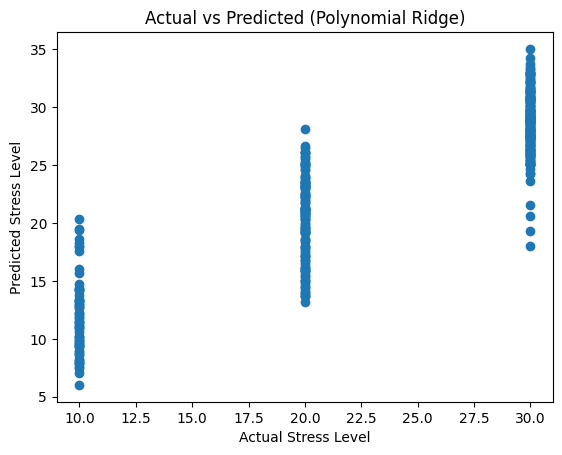

In [14]:
# -----------------------------
# Actual vs Predicted Plot
# -----------------------------
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Stress Level")
plt.ylabel("Predicted Stress Level")
plt.title("Actual vs Predicted (Polynomial Ridge)")
plt.show()

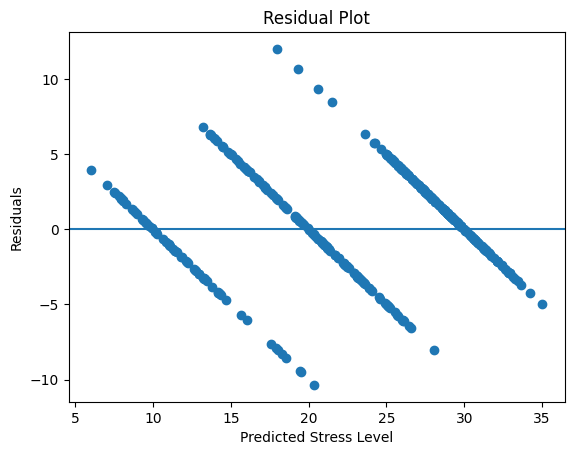

In [15]:
# -----------------------------
# Residual Plot
# -----------------------------
residuals = y_test - y_pred
plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Stress Level")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

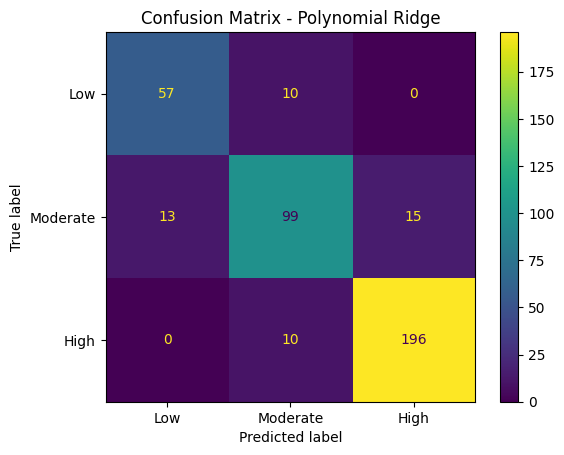

In [16]:
# -----------------------------
# Confusion Matrix (Category View)
# -----------------------------
def score_to_category(score):
    if score < 15:
        return "Low"
    elif score < 25:
        return "Moderate"
    else:
        return "High"

y_test_cat = [score_to_category(v) for v in y_test]
y_pred_cat = [score_to_category(v) for v in y_pred]

cm = confusion_matrix(y_test_cat, y_pred_cat, labels=["Low", "Moderate", "High"])
disp = ConfusionMatrixDisplay(cm, display_labels=["Low", "Moderate", "High"])
disp.plot()
plt.title("Confusion Matrix - Polynomial Ridge")
plt.show()

In [17]:
# -----------------------------
# Save model
# -----------------------------
joblib.dump(model, "stress_model_linear_advanced.pkl")
joblib.dump(label_encoders, "encoders.pkl")

print("\n✅ Advanced Linear Model saved as stress_model_linear_advanced.pkl")



✅ Advanced Linear Model saved as stress_model_linear_advanced.pkl
